# Travelling Salesman Problem
[Travelling Salesman Problem](https://en.wikipedia.org/wiki/Travelling_salesman_problem) adalah masalah optimisasi kombinatorial NP-hard yang sangat terkenal, yang menanyakan: "Diberikan daftar kota dan jarak antar setiap pasangan kota, berapakah rute terpendek yang mengunjungi setiap kota dan kembali ke kota asal?"

Untuk permasalahan ini, kromosom dipilih sebagai himpunan kota. Jadi, urutan kromosom $[3,1,4,0,2]$ berarti urutan kota yang dikunjungi adalah $3\rightarrow 1\rightarrow 4\rightarrow 0\rightarrow 2\rightarrow 3$.

### Genetic Algorithm Process
Genetic algorithm secara iteratif menyelesaikan masalah ini menggunakan evaluasi fitness, seleksi orang tua, crossover, dan mutation. Berikut adalah penjelasan langkah-langkah ini dengan contoh:

#### 1. Fitness Calculation
Fungsi fitness mengevaluasi kualitas setiap rute. Rute dengan jarak lebih pendek memiliki nilai fitness lebih tinggi. Fitness dihitung sebagai:
$$fitness = e^{DNA_{size} * 2 / total\_distance}$$
Contohnya:
- Population: $[[0, 2, 1, 3], [1, 3, 0, 2], [2, 0, 3, 1]]$
- City Positions: $[[0, 0], [1, 2], [2, 0], [3, 3]]$ (koordinat untuk kota 0, 1, 2, 3) 
- Total Distances: $[7.211, 8.485, 7.616]$
- Fitness: $[0.00365, 0.00274, 0.00339]$

#### 2. Parent Selection
Orang tua dipilih berdasarkan fitness menggunakan roulette wheel sampling. Individu dengan fitness lebih tinggi memiliki peluang lebih besar untuk terpilih.
Sebagai contoh, dengan nilai fitness $[0.00365, 0.00274, 0.00339]$, populasi yang terpilih mungkin menjadi:
$[[0, 2, 1, 3], [2, 0, 3, 1], [0, 2, 1, 3]]$

#### 3. Crossover
Selama crossover, sebagian gen (kota) dari satu parent digabungkan dengan gen dari parent lain untuk menghasilkan offspring, sehingga tidak ada kota yang duplikat. Contohnya:
- Parent 1: $[0, 2, 1, 3]$
- Parent 2: $[2, 0, 3, 1]$
- Random Mask: $[True, False, True, False]$
- Offspring: $[2, 3, 0, 1]$

#### 4. Mutation
Mutation dipakai untuk menjaga keragaman solusi agar populasi tidak cepat terjebak pada solusi lokal. Mutation membuat keragaman dengan menukar dua kota dalam sebuah rute dengan probabilitas kecil. Contohnya: (Jika kota pada posisi 1 dan 3 ditukar)
- Sebelum Mutation: $[2, 3, 0, 1]$
- Setelah Mutation: $[2, 1, 0, 3]$

#### Evolution
Populasi berevolusi sepanjang generasi dengan memilih orang tua, menerapkan crossover, dan memutasi offspring. Proses ini meningkatkan solusi secara iteratif.

### Example
Starting Population: $[[0, 2, 1, 3], [1, 3, 0, 2], [2, 0, 3, 1]]$
Evolved Population: $[[0, 3, 2, 1], [2, 1, 0, 3], [1, 0, 2, 3]]$


In [7]:
import matplotlib.pyplot as plt
import numpy as np

N_CITIES = 20  # DNA size
CROSS_RATE = 0.1
MUTATE_RATE = 0.02
POP_SIZE = 500
N_GENERATIONS = 350

class GA(object):
    def __init__(self, DNA_size, cross_rate, mutation_rate, pop_size):
        self.DNA_size = DNA_size
        self.cross_rate = cross_rate
        self.mutate_rate = mutation_rate
        self.pop_size = pop_size

        self.pop = np.vstack([np.random.permutation(DNA_size) for _ in range(pop_size)])

    def translateDNA(self, DNA, city_position):     # get cities' coord in order
        line_x = np.empty_like(DNA, dtype=np.float64)
        line_y = np.empty_like(DNA, dtype=np.float64)
        for i, d in enumerate(DNA):
            city_coord = city_position[d]
            line_x[i, :] = city_coord[:, 0]
            line_y[i, :] = city_coord[:, 1]
        return line_x, line_y

    def get_fitness(self, line_x, line_y):
        total_distance = np.empty((line_x.shape[0],), dtype=np.float64)
        for i, (xs, ys) in enumerate(zip(line_x, line_y)):
            total_distance[i] = np.sum(np.sqrt(np.square(np.diff(xs)) + np.square(np.diff(ys))))
        fitness = np.exp(self.DNA_size * 2 / total_distance)
        return fitness, total_distance

    def select(self, fitness):
        idx = np.random.choice(np.arange(self.pop_size), size=self.pop_size, replace=True, p=fitness / fitness.sum())
        return self.pop[idx]

    def crossover(self, parent, pop):
        if np.random.rand() < self.cross_rate:
            i_ = np.random.randint(0, self.pop_size, size=1)                        # select another individual from pop
            cross_points = np.random.randint(0, 2, self.DNA_size).astype(np.bool_)    # choose crossover points
            keep_city = parent[~cross_points]                                       # find the city number
            swap_city = pop[i_, np.isin(pop[i_].ravel(), keep_city, invert=True)]
            parent[:] = np.concatenate((keep_city, swap_city))
        return parent

    def mutate(self, child):
        for point in range(self.DNA_size):
            if np.random.rand() < self.mutate_rate:
                swap_point = np.random.randint(0, self.DNA_size)
                swapA, swapB = child[point], child[swap_point]
                child[point], child[swap_point] = swapB, swapA
        return child

    def evolve(self, fitness):
        pop = self.select(fitness)
        pop_copy = pop.copy()
        for parent in pop:  # for every parent
            child = self.crossover(parent, pop_copy)
            child = self.mutate(child)
            parent[:] = child
        self.pop = pop

class TravelSalesPerson(object):
    def __init__(self, n_cities):
        self.city_position = np.random.rand(n_cities, 2)
        plt.ion()
        self.iter = 0

    def plotting(self, lx, ly, total_d, save=False):
        plt.cla()
        plt.scatter(self.city_position[:, 0].T, self.city_position[:, 1].T, s=100, c='k')
        plt.plot(lx.T, ly.T, 'r-')
        plt.text(-0.05, -0.05, "Total distance=%.2f" % total_d, fontdict={'size': 20, 'color': 'red'})
        plt.xlim((-0.1, 1.1))
        plt.ylim((-0.1, 1.1))
        if save: plt.savefig('Images/travelling_salesman/travelling_salesman_{:03d}'.format(self.iter))
        if self.iter%50==0: plt.show()
        self.iter += 1

In [8]:
env = TravelSalesPerson(N_CITIES)

Gen: 0 | best fit: 192.75


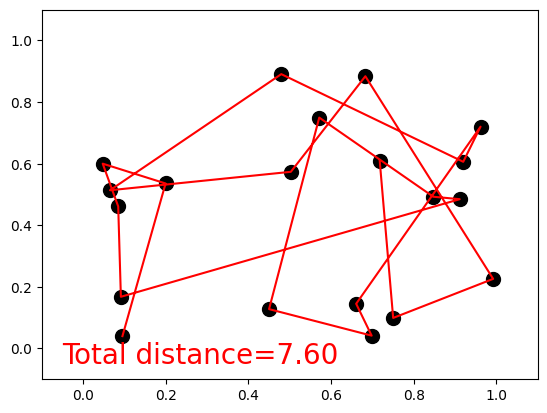

Gen: 50 | best fit: 5430.33


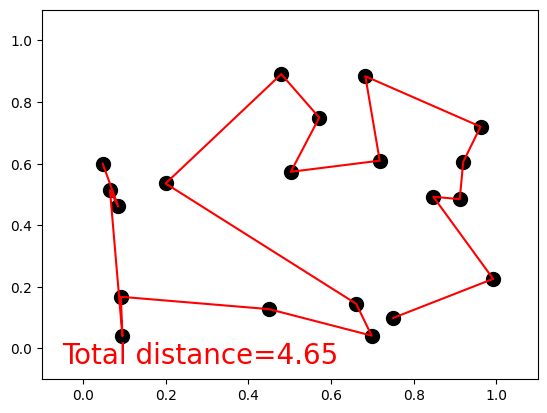

Gen: 100 | best fit: 9142.72


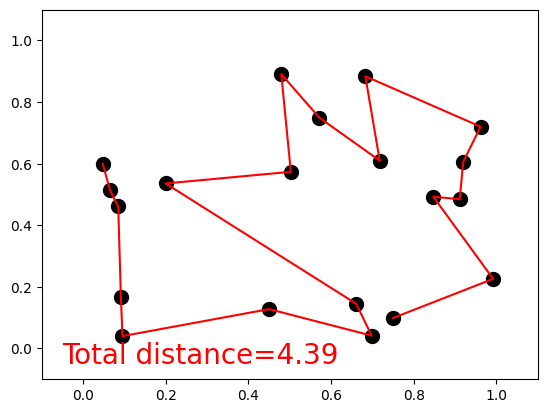

Gen: 150 | best fit: 9523.78


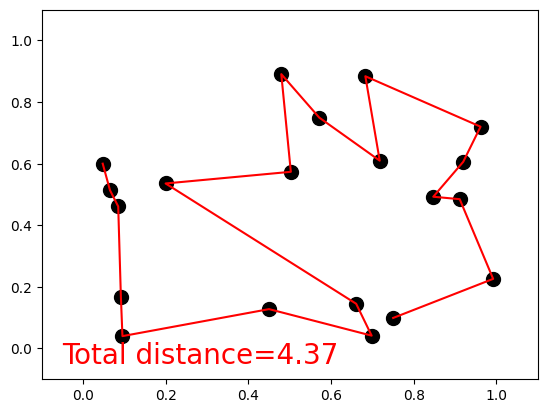

Gen: 200 | best fit: 14230.12


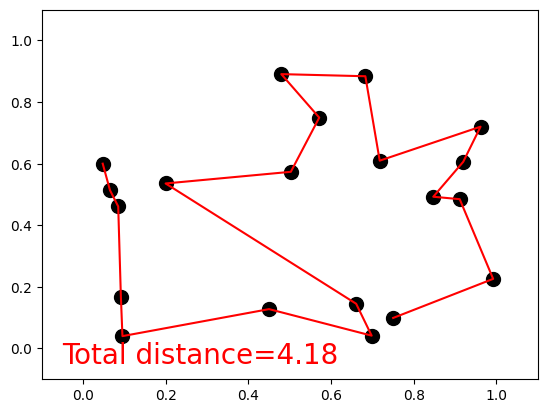

Gen: 250 | best fit: 14230.12


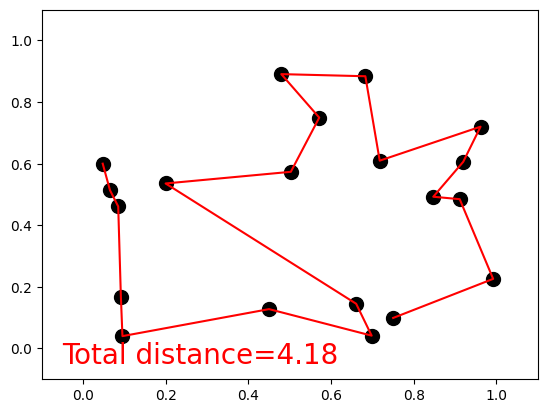

Gen: 300 | best fit: 14230.12


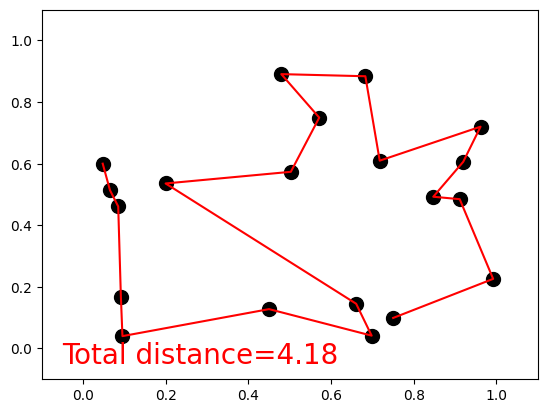

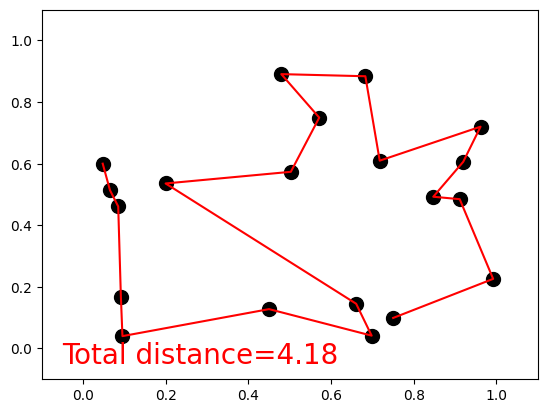

In [9]:
n_runs = 20
fitness_max = np.zeros((n_runs, N_GENERATIONS))
for i in range(n_runs):
    ga = GA(DNA_size=N_CITIES, cross_rate=CROSS_RATE, mutation_rate=MUTATE_RATE, pop_size=POP_SIZE)
    for generation in range(N_GENERATIONS):
        lx, ly = ga.translateDNA(ga.pop, env.city_position)
        fitness, total_distance = ga.get_fitness(lx, ly)
        ga.evolve(fitness)
        best_idx = np.argmax(fitness)
        fitness_max[i, generation] = total_distance[best_idx]
        if i==0:
            if generation%50==0: print('Gen:', generation, '| best fit: %.2f' % fitness[best_idx],)
            env.plotting(lx[best_idx], ly[best_idx], total_distance[best_idx])

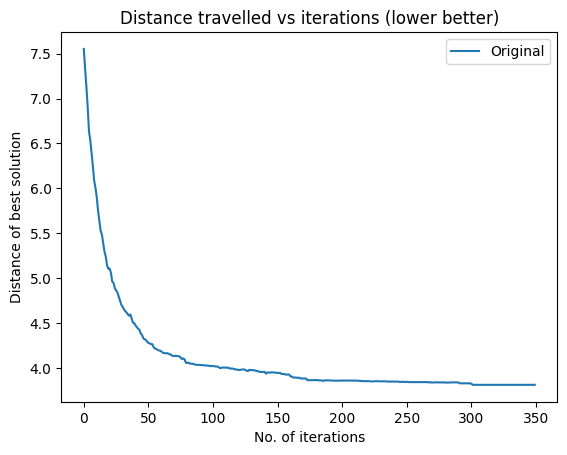

In [10]:
plt.plot(np.average(fitness_max, axis=0), label='Original')
plt.title('Distance travelled vs iterations (lower better)')
plt.xlabel('No. of iterations')
plt.ylabel('Distance of best solution')
plt.legend()